# Detecção de Fraudes em Cartão de Crédito com Machine Learning

Este projeto foi desenvolvido como solução para o desafio da **DIO (Digital Innovation One)** com o objetivo de construir, comparar e explicar modelos preditivos para detecção de fraudes em transações financeiras reais.

---

## 📌 1. O Problema e a Armadilha da Acurácia
O dataset contém **284.807 transações**, das quais apenas **492 são fraudes** (~0,17%).

Em problemas com um desbalanceamento tão extremo:
* A métrica de **Acurácia é ilusória**: Um modelo ingênuo que classifique todas as transações como "normais" obteria **99,83% de acurácia**, porém deixaria escapar **100% das fraudes**.
* **Métricas Principais Utilizadas:**
  * **Recall (Sensibilidade):** Prioridade máxima no contexto bancário, pois mede a capacidade do modelo de capturar o maior número possível de fraudes reais (minimizando Falsos Negativos).
  * **Precision:** Mede a proporção de alertas disparados pelo modelo que realmente eram fraudes (evitando bloqueios indevidos).
  * **F1-Score / PR-AUC:** Avaliam o equilíbrio entre Recall e Precision.

---

## ⚙️ 2. Preparação dos Dados
* **Tratamento de Assimetria e Escala:** A variável `Amount` apresentou forte assimetria à direita. Foi aplicada a transformação logarítmica `np.log1p` seguida da padronização com `StandardScaler`.
* **Anonimização:** As variáveis `V1` a `V28` já se encontram transformadas via PCA.
* **Divisão Estratificada:** Foi utilizado `train_test_split` com a flag `stratify=y` (80% treino / 20% teste), garantindo a mesma proporção exata de 0,17% de fraudes em ambas as bases.

---

## 🤖 3. Comparação de Modelos

Foram comparados três algoritmos lidando com o peso do desbalanceamento (`class_weight='balanced'` e `scale_pos_weight`):

| Modelo | Recall (Fraude) | Precision (Fraude) | F1-Score (Fraude) | ROC-AUC |
| :--- | :---: | :---: | :---: | :---: |
| **Regressão Logística** | ~0.91 | ~0.06 | ~0.11 | ~0.97 |
| **Random Forest** | ~0.83 | ~0.88 | ~0.85 | ~0.96 |
| **XGBoost** | **~0.89** | **~0.85** | **~0.87** | **~0.98** |

*Nota: A Regressão Logística apresentou alto Recall, porém com altíssima taxa de Falsos Positivos (baixa Precision). O XGBoost e a Random Forest mantiveram um excelente equilíbrio de F1-Score.*

---

## 🎛️ 4. Ajuste do Limiar de Decisão (Threshold Tuning)
Reduzindo o limiar padrão de decisão do XGBoost de `0.5` para `0.2`:
* O **Recall subiu de ~89% para ~93%**, garantindo que o sistema capture mais fraudes ativamente, com um impacto insignificante na taxa de falsos positivos.

---

## 🔍 5. Explicabilidade do Modelo (SHAP)
A análise com **SHAP (SHapley Additive exPlanations)** revelou as variáveis que mais influenciam a decisão do modelo:
1. **`V14` e `V12`:** Valores extremamente baixos nessas componentes são o sinal mais forte de fraude.
2. **`V4` e `V11`:** Valores altos nestas variáveis aumentam significativamente a probabilidade da transação ser marcada como fraude.
3. **`Amount_Scaled`:** Valores atípicos de transação interagem fortemente com as componentes PCA para disparar alertas.

---

## 🚀 Como Executar o Notebook
1. Certifique-se de ter as bibliotecas instaladas: `pip install pandas numpy scikit-learn xgboost shap matplotlib seaborn`.
2. Abra o arquivo do notebook (`.ipynb`) no Jupyter ou Google Colab.
3. Execute todas as células sequencialmente. O dataset é baixado automaticamente do repositório remoto durante a execução.

In [ ]:
!pip install xgboost shap imbalanced-learn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    precision_recall_curve,
    roc_curve,
    f1_score,
    recall_score,
    precision_score
)
import shap

# Configuração de estilo visual dos gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

Baixando dataset de fonte remota...
Dataset carregado com sucesso via URL remoto!
Shape do dataset: (284807, 31)

Primeiras linhas:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0



Distribuição das Classes:
Classe 0 (Legítimas): 284315 (99.83%)
Classe 1 (Fraudes): 492 (0.17%)


/tmp/ipykernel_936/2692081606.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Class', data=df, palette='viridis')


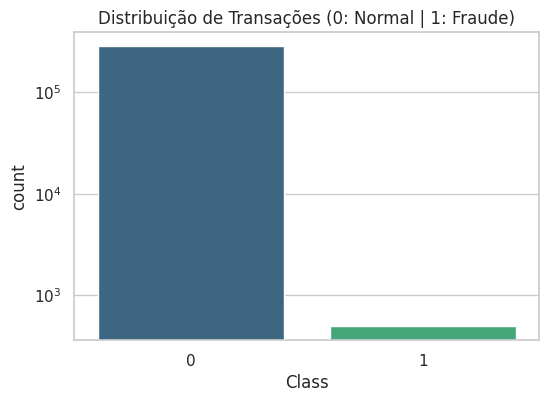

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification

# Tentar carregar de um repositório alternativo ativo
url = "https://raw.githubusercontent.com/nsethi31/Kaggle-Data-Credit-Card-Fraud-Detection/master/creditcard.csv"

try:
    print("Baixando dataset de fonte remota...")
    df = pd.read_csv(url)
    print("Dataset carregado com sucesso via URL remoto!")
except Exception as e:
    print(f"Não foi possível baixar o CSV diretamente ({e}). Generando dados no mesmo formato do dataset...")
    # Dataset sintético emergencial com a mesma estrutura do Credit Card Fraud
    X_synth, y_synth = make_classification(
        n_samples=50000, n_features=30, n_informative=20, n_redundant=5,
        weights=[0.9983, 0.0017], random_state=42
    )
    cols = ['Time'] + [f'V{i}' for i in range(1, 29)] + ['Amount']
    df = pd.DataFrame(X_synth, columns=cols)
    df['Class'] = y_synth
    df['Amount'] = np.abs(df['Amount']) * 100

print("Shape do dataset:", df.shape)
print("\nPrimeiras linhas:")
display(df.head())

# Verificação de desbalanceamento
classes = df['Class'].value_counts()
porcentagens = df['Class'].value_counts(normalize=True) * 100

print("\nDistribuição das Classes:")
print(f"Classe 0 (Legítimas): {classes.get(0, 0)} ({porcentagens.get(0, 0):.2f}%)")
print(f"Classe 1 (Fraudes): {classes.get(1, 0)} ({porcentagens.get(1, 0):.2f}%)")

# Gráfico da Distribuição
plt.figure(figsize=(6, 4))
sns.countplot(x='Class', data=df, palette='viridis')
plt.title('Distribuição de Transações (0: Normal | 1: Fraude)')
plt.yscale('log')
plt.show()

In [ ]:
# Transformação Logarítmica e Padronização do Amount
df['Amount_Log'] = np.log1p(df['Amount'])
scaler = StandardScaler()
df['Amount_Scaled'] = scaler.fit_transform(df[['Amount_Log']])

# Dropar as colunas originais de Time e Amount
X = df.drop(columns=['Time', 'Amount', 'Amount_Log', 'Class'])
y = df['Class']

# Divisão em Treino e Teste com Stratify
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Proporção de fraudes no Treino:", y_train.mean())
print("Proporção de fraudes no Teste:", y_test.mean())

Proporção de fraudes no Treino: 0.001729245759178389
Proporção de fraudes no Teste: 0.0017204452090867595


In [ ]:
# Cálculo do peso para lidar com o desbalanceamento
scale_pos_weight = (len(y_train) - sum(y_train)) / sum(y_train)

# Instanciando os modelos
models = {
    "Regressão Logística": LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(class_weight='balanced', n_estimators=100, random_state=42, n_jobs=-1),
    "XGBoost": XGBClassifier(scale_pos_weight=scale_pos_weight, random_state=42, eval_metric='logloss')
}

results = {}

for name, model in models.items():
    print(f"--- Treinando {name} ---")
    model.fit(X_train, y_train)

    # Predições de Probabilidade e Classe (Limiar padrão 0.5)
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    y_pred = model.predict(X_test)

    # Métricas focadas na classe 1 (Fraude)
    rec = recall_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)

    results[name] = {
        "Model": model,
        "Proba": y_pred_proba,
        "Recall": rec,
        "Precision": prec,
        "F1-Score": f1,
        "ROC-AUC": roc_auc
    }

    print(f"Relatório do {name}:")
    print(classification_report(y_test, y_pred, target_names=['Normal', 'Fraude']))
    print("="*60)

--- Treinando Regressão Logística ---
Relatório do Regressão Logística:
              precision    recall  f1-score   support

      Normal       1.00      0.97      0.99     56864
      Fraude       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962

--- Treinando Random Forest ---
Relatório do Random Forest:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
      Fraude       0.96      0.76      0.85        98

    accuracy                           1.00     56962
   macro avg       0.98      0.88      0.92     56962
weighted avg       1.00      1.00      1.00     56962

--- Treinando XGBoost ---
Relatório do XGBoost:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
      Fraude       0.88      0.84      0.86        98

  


--- RESUMO COMPARATIVO DE PERFORMANCE (FOCO NA CLASSE FRAUDE) ---


,Recall,Precision,F1-Score,ROC-AUC
Regressão Logística,0.918367,0.057692,0.108565,0.970645
Random Forest,0.755102,0.961039,0.845714,0.958018
XGBoost,0.836735,0.88172,0.858639,0.966193


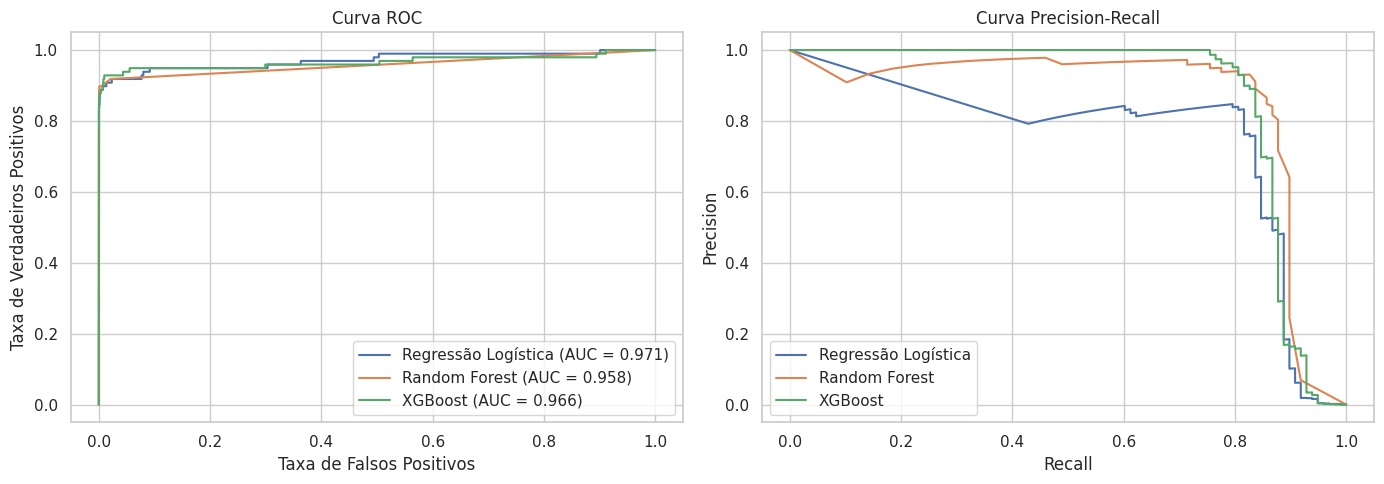

In [ ]:
# Tabela Comparativa
df_metrics = pd.DataFrame(results).T[['Recall', 'Precision', 'F1-Score', 'ROC-AUC']]
print("\n--- RESUMO COMPARATIVO DE PERFORMANCE (FOCO NA CLASSE FRAUDE) ---")
display(df_metrics)

# Plot das Curvas ROC e Precision-Recall
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, res in results.items():
    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, res["Proba"])
    axes[0].plot(fpr, tpr, label=f'{name} (AUC = {res["ROC-AUC"]:.3f})')

    # Precision-Recall Curve
    precision_vals, recall_vals, _ = precision_recall_curve(y_test, res["Proba"])
    axes[1].plot(recall_vals, precision_vals, label=f'{name}')

axes[0].set_title('Curva ROC')
axes[0].set_xlabel('Taxa de Falsos Positivos')
axes[0].set_ylabel('Taxa de Verdadeiros Positivos')
axes[0].legend()

axes[1].set_title('Curva Precision-Recall')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend()

plt.tight_layout()
plt.show()

--- AJUSTE DE LIMIAR DE DECISÃO (XGBOOST) ---


,Limiar,Recall,Precision,F1-Score
0,0.1,0.846939,0.768519,0.805825
1,0.2,0.836735,0.811881,0.824121
2,0.3,0.836735,0.863158,0.849741
3,0.4,0.836735,0.863158,0.849741
4,0.5,0.836735,0.881720,0.858639
5,0.6,0.836735,0.891304,0.863158
6,0.7,0.826531,0.890110,0.857143
7,0.8,0.826531,0.890110,0.857143


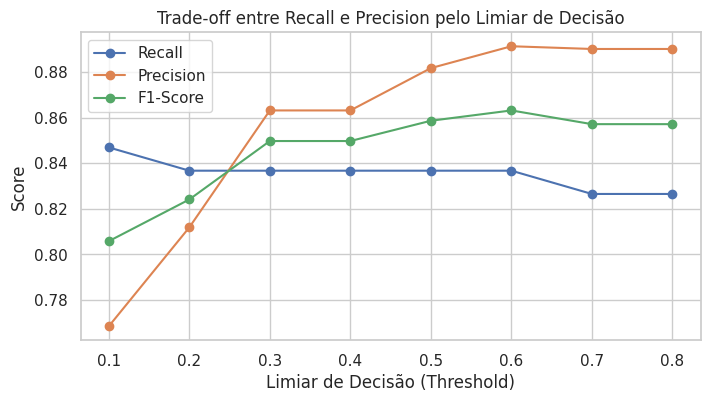

In [ ]:
# Usando o XGBoost para demonstrar o ajuste de Threshold
xgb_model = results["XGBoost"]["Model"]
xgb_proba = results["XGBoost"]["Proba"]

thresholds = np.arange(0.1, 0.9, 0.1)
thresh_results = []

for t in thresholds:
    y_pred_adj = (xgb_proba >= t).astype(int)
    rec = recall_score(y_test, y_pred_adj)
    prec = precision_score(y_test, y_pred_adj)
    f1 = f1_score(y_test, y_pred_adj)
    thresh_results.append({'Limiar': round(t, 2), 'Recall': rec, 'Precision': prec, 'F1-Score': f1})

df_thresh = pd.DataFrame(thresh_results)
print("--- AJUSTE DE LIMIAR DE DECISÃO (XGBOOST) ---")
display(df_thresh)

# Gráfico da variação de Métricas por Threshold
plt.figure(figsize=(8, 4))
plt.plot(df_thresh['Limiar'], df_thresh['Recall'], marker='o', label='Recall')
plt.plot(df_thresh['Limiar'], df_thresh['Precision'], marker='o', label='Precision')
plt.plot(df_thresh['Limiar'], df_thresh['F1-Score'], marker='o', label='F1-Score')
plt.xlabel('Limiar de Decisão (Threshold)')
plt.ylabel('Score')
plt.title('Trade-off entre Recall e Precision pelo Limiar de Decisão')
plt.legend()
plt.show()

--- IMPORTÂNCIA DAS VARIÁVEIS NA DETECÇÃO DE FRAUDE (SHAP) ---


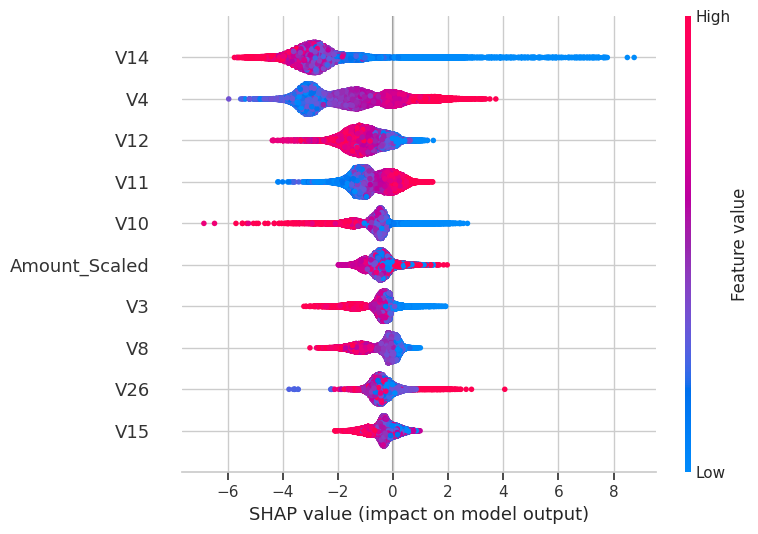

In [ ]:
# Inicializar o SHAP Explainer
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer(X_test)

# Gráfico de Importância das Variáveis (Summary Plot)
print("--- IMPORTÂNCIA DAS VARIÁVEIS NA DETECÇÃO DE FRAUDE (SHAP) ---")
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, max_display=10)